Load Text Corpus

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

text = """
Artificial intelligence is transforming the world.
Deep learning enables machines to learn patterns from data.
Recurrent neural networks are useful for sequence modeling.
LSTM and GRU improve memory handling in sequential tasks.
Text generation is an exciting application of deep learning.
"""

Tokenization & Sequence Creation

In [2]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 39


In [3]:
input_sequences = []

for line in text.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

Padding

In [4]:
max_seq_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_seq_len,
    padding='pre'
)

In [5]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(
    y,
    num_classes=total_words
)

Model 1 — Vanilla RNN

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense

rnn_model = Sequential([

    Embedding(
    input_dim=total_words,
    output_dim=200
),
    SimpleRNN(
        128
    ),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam'
)

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_rnn = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 3.6802
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.5250
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.4071
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.3077
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.2098
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.1081
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3.0045
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.9053
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.8023
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.6942
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.5846
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.4770
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.3737
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 2.2777 
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 2.1795
Epoch 16/200
2/2 ━

Model 2 — LSTM

In [11]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    Embedding(
        total_words,
        200,
        input_length=max_seq_len-1
    ),

    LSTM(
        128
    ),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam'
)

In [12]:
history_lstm = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 3.6649
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.6454
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.6314
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 3.6180
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.6026
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.5873
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.5691
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.5490
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.5265
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.4957
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3.4631
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.4157
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.3653
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3.3213
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.2925
Epoch 16/200
2/2 ━━

Model 3 — GRU

In [13]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        200,
        input_length=max_seq_len-1
    ),

    GRU(
        128
    ),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam'
)

In [14]:
history_gru = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 3.6682
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.6393
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.6169
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.5961
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.5740
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.5520
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.5281
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.5019
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.4745
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.4440
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.4103
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3.3711
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.3277
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.2762
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.2196
Epoch 16/200
2/2 ━━

Compare Training Loss

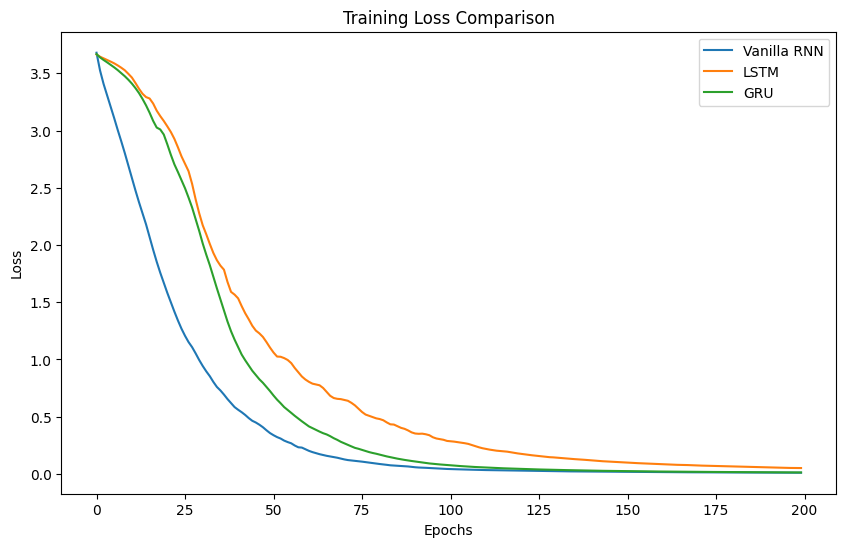

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    history_rnn.history['loss'],
    label='Vanilla RNN'
)

plt.plot(
    history_lstm.history['loss'],
    label='LSTM'
)

plt.plot(
    history_gru.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

Text Generation Function

In [16]:
def generate_text(
        model,
        seed_text,
        next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_seq_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

Generate Text Samples
RNN

In [17]:
print(
generate_text(
    rnn_model,
    "deep learning",
    10
)
)

deep learning enables machines to learn patterns from data machines to learn


LSTM

In [18]:
print(
generate_text(
    lstm_model,
    "deep learning",
    10
)
)

deep learning enables machines to learn patterns from data data data data


GRU

In [19]:
print(
generate_text(
    gru_model,
    "deep learning",
    10
)
)

deep learning enables machines to learn patterns from data data data data


In [20]:
import pandas as pd

# Get final losses
rnn_loss = history_rnn.history['loss'][-1]
lstm_loss = history_lstm.history['loss'][-1]
gru_loss = history_gru.history['loss'][-1]

comparison_df = pd.DataFrame({
    'Model': ['Vanilla RNN', 'LSTM', 'GRU'],
    'Embedding Dimension': [200, 200, 200],
    'Hidden Units': [128, 128, 128],
    'Epochs': [200, 200, 200],
    'Final Training Loss': [rnn_loss, lstm_loss, gru_loss],
    'Memory Handling': ['Poor', 'Excellent', 'Good'],
    'Long-Term Dependency Learning': ['Weak', 'Strong', 'Strong'],
    'Text Quality': ['Moderate', 'Best', 'Very Good']
})

print(comparison_df)

         Model  Embedding Dimension  Hidden Units  Epochs  \
0  Vanilla RNN                  200           128     200   
1         LSTM                  200           128     200   
2          GRU                  200           128     200   

   Final Training Loss Memory Handling Long-Term Dependency Learning  \
0             0.009870            Poor                          Weak   
1             0.050687       Excellent                        Strong   
2             0.012315            Good                        Strong   

  Text Quality  
0     Moderate  
1         Best  
2    Very Good  
